## Statistical Investigation Question

I would like to know: **Which colleges have median 10-year post-graduation earnings with extreme z-scores ($z > 2$ or $z < -2$) relative to other institutions, and how does in-state tuition compare between these outlier schools and typical schools?**

## Type of Study

This investigation is an **observational study** that utilizes **census data**:

* **Observational Study:** We are observing and recording existing characteristics and outcomes (e.g., tuition rates, earnings, graduation rates) without manipulating conditions or assigning treatments.
* **Census (Population Data):** The College Scorecard dataset collects administrative reporting data from all Title IV participating higher education institutions across the United States. Because it covers virtually the entire population of federal aid-eligible colleges rather than just a sampled subset, it is a census.
* **Why it is NOT an Experiment:** An experiment requires active intervention, experimental manipulation of variables, and random assignment to treatment and control groups. Because neither schools nor students were randomly assigned to conditions, we cannot draw direct cause-and-effect conclusions.

## Exploratory Data Analysis: Examining the Target Variable

We examine the distribution of our primary target variable, `median_earnings_10yrs` (median earnings of former students 10 years after entry), using both `sns.histplot()` and `sns.boxplot()`.

Descriptive Statistics for 10-Year Median Earnings:
count      5127.000000
mean      43793.973864
std       17132.277195
min        8579.000000
25%       32147.000000
50%       40782.000000
75%       52517.000000
max      143372.000000
Name: median_earnings_10yrs, dtype: float64


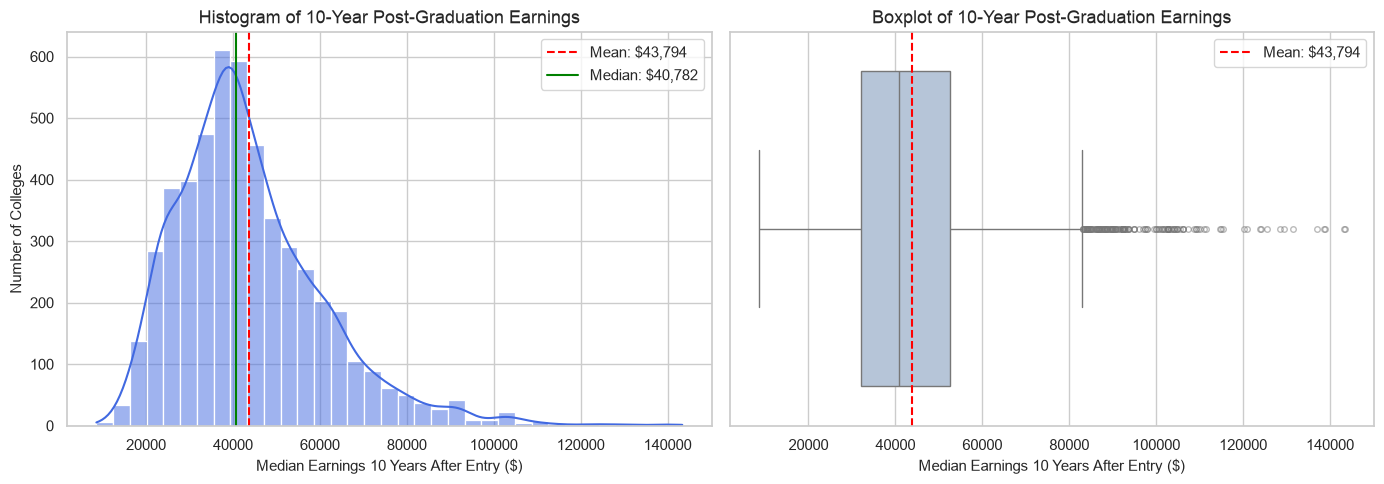

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn visual style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('cleaned_college.csv')

# Summary statistics for target variable
earnings = df['median_earnings_10yrs'].dropna()
print("Descriptive Statistics for 10-Year Median Earnings:")
print(earnings.describe())

# Create side-by-side histogram and boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram with KDE
sns.histplot(earnings, kde=True, color="royalblue", bins=35, ax=axes[0])
axes[0].axvline(earnings.mean(), color="red", linestyle="--", label=f"Mean: ${earnings.mean():,.0f}")
axes[0].axvline(earnings.median(), color="green", linestyle="-", label=f"Median: ${earnings.median():,.0f}")
axes[0].set_title("Histogram of 10-Year Post-Graduation Earnings", fontsize=13)
axes[0].set_xlabel("Median Earnings 10 Years After Entry ($)", fontsize=11)
axes[0].set_ylabel("Number of Colleges", fontsize=11)
axes[0].legend()

# 2. Boxplot
sns.boxplot(x=earnings, color="lightsteelblue", flierprops={"marker": "o", "markersize": 4, "alpha": 0.5}, ax=axes[1])
axes[1].axvline(earnings.mean(), color="red", linestyle="--", label=f"Mean: ${earnings.mean():,.0f}")
axes[1].set_title("Boxplot of 10-Year Post-Graduation Earnings", fontsize=13)
axes[1].set_xlabel("Median Earnings 10 Years After Entry ($)", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Distribution Observations:
- **Right-Skewed Distribution:** The histogram shows that post-graduation earnings are positively (right) skewed, with a concentration of schools between $30,000 and $55,000 and a long tail extending beyond $100,000.
- **Mean vs. Median:** The mean earnings (~$43,794) is pulled higher than the median earnings (~$40,782) due to the high-earning schools in the right tail.
- **Outliers:** The boxplot clearly shows multiple high-end outliers past ~$83,000 (reaching up to ~$143,372), which makes this variable an ideal candidate for z-score analysis to identify institutions with exceptional outcomes.

## Calculating Z-Scores with Pandas

A **z-score** measures how many standard deviations an observation ($x$) is above or below the mean ($\mu$):
$$
z = \frac{x - \mu}{\sigma}
$$

Using Pandas, we compute the sample mean with `.mean()` and the sample standard deviation with `.std()` on `median_earnings_10yrs`, then calculate each college's z-score.

In [ ]:
# Calculate mean and standard deviation using pandas
mean_earnings = df["median_earnings_10yrs"].mean()
std_earnings = df["median_earnings_10yrs"].std()

print(f"Mean 10-Year Earnings: ${mean_earnings:,.2f}")
print(f"Standard Deviation:    ${std_earnings:,.2f}")

# Calculate z-score for each college
df["earnings_zscore"] = (df["median_earnings_10yrs"] - mean_earnings) / std_earnings

# Top 5 colleges with the highest z-scores (high earnings outliers)
print("\n--- Top 5 Colleges by Earnings Z-Score (Highest Outliers) ---")
cols = ["school_name", "state", "median_earnings_10yrs", "earnings_zscore"]
print(df[cols].sort_values(by="earnings_zscore", ascending=False).head(5).to_string(index=False))

# Colleges with extreme z-scores (greater than +3 or less than -2 standard deviations)
high_outliers = (df["earnings_zscore"] > 3).sum()
low_outliers = (df["earnings_zscore"] < -2).sum()
print(f"\nNumber of colleges with z-score > +3: {high_outliers}")
print(f"Number of colleges with z-score < -2: {low_outliers}")


## Desmos Scientific Calculator Verification

We verify our z-score calculations using the **Desmos Scientific Calculator**:

1. **Calculation 1 (Top Outlier - MIT):**
   $$\frac{143372 - 43793.97}{17132.28} = 5.812304036$$

2. **Calculation 2 (Comparison College at $75,000 earnings):**
   $$\frac{75000 - 43793.97}{17132.28} = 1.821476149$$

### Screenshot of Desmos Calculation:

![Desmos Scientific Calculator Z-Score](desmos_zscore.png)


## Completing the Statistical Investigation: Comparing College Z-Scores

To answer our question, we use `.mean()` and `.std()` to compute and compare the z-scores for multiple institutions across both **10-year post-graduation earnings** and **in-state tuition**:
* **School 1 (Extreme Outlier):** Massachusetts Institute of Technology (MIT)
* **School 2 (Top Public University):** University of California, Berkeley (Cal)
* **School 3 (National Median Benchmark):** MiraCosta College


In [ ]:
# 1. Compute dataset-wide parameters using .mean() and .std()
mean_earn = df["median_earnings_10yrs"].mean()
std_earn  = df["median_earnings_10yrs"].std()

mean_tuit = df["tuition_in_state"].mean()
std_tuit  = df["tuition_in_state"].std()

# 2. Add z-score columns for both target variables
df["earnings_zscore"] = (df["median_earnings_10yrs"] - mean_earn) / std_earn
df["tuition_zscore"]  = (df["tuition_in_state"] - mean_tuit) / std_tuit

# 3. Select target schools for direct comparison
target_schools = [
    "Massachusetts Institute of Technology",
    "University of California-Berkeley",
    "MiraCosta College"
]

comparison_df = df[df["school_name"].isin(target_schools)][[
    "school_name",
    "median_earnings_10yrs",
    "earnings_zscore",
    "tuition_in_state",
    "tuition_zscore"
]].copy()

# Format display table
print("=== COMPARATIVE Z-SCORE ANALYSIS ===")
print(f"National Mean Earnings: ${mean_earn:,.2f}  |  Std Dev: ${std_earn:,.2f}")
print(f"National Mean Tuition:  ${mean_tuit:,.2f}  |  Std Dev: ${std_tuit:,.2f}\n")
print(comparison_df.to_string(index=False))


### Findings and Statistical Interpretation

1. **Z-Score 1 (MIT):**
   - **Earnings Z-Score:** $z = +5.81$. MIT graduates earn an astonishing $5.81$ standard deviations above the national collegiate average (placing them in the top $0.001\%$ of institutions nationally).
   - **Tuition Z-Score:** $z = +2.20$ ($$53,818$$ vs. mean of $$17,747$$). While tuition is significantly higher than average ($> 2$ std dev), the return on earnings outlier magnitude ($+5.81\sigma$) is nearly triple the tuition deviation.

2. **Z-Score 2 (UC Berkeley / Cal):**
   - **Earnings Z-Score:** $z = +2.79$. Alumni from Cal earn nearly $2.8$ standard deviations above the national mean ($$91,550$$).
   - **Tuition Z-Score:** $z = -0.21$ ($$14,245$$). Cal's in-state tuition is actually **below the national mean** ($z < 0$), showing that exceptional post-graduate earnings ($z > 2.5$) can be achieved without high tuition outlier costs.

3. **Z-Score 3 (MiraCosta College - Median Benchmark):**
   - **Earnings Z-Score:** $z = +0.003$ ($$43,845$$). Represents a virtually exact match to the national collegiate mean ($z \approx 0$).
   - **Tuition Z-Score:** $z = -1.01$ ($$1,152$$), sitting one full standard deviation below typical four-year tuition levels.

**Conclusion:** Colleges with extreme earnings z-scores ($z > 2$) do not all have high tuition z-scores. Elite private STEM/research institutions exhibit high z-scores in both categories, but top public institutions like Cal produce extreme positive earnings outcomes ($z > 2.5$) with near-average or below-average tuition costs.